In [15]:
import numpy as np

# ===============================
# CONSTANTS
# ===============================
mu = 398600.4418         # km^3/s^2, Earth's gravitational parameter
Re = 6378.137            # km, Earth's equatorial radius
J2 = 1.08263e-3          # Earth's J2 coefficient
omega_earth = 7.2921159e-5  # rad/s, Earth's rotation rate

# ===============================
# INPUT ORBIT PARAMETERS
# ===============================
h = 474.066              # km (altitude)
a = Re + h               # km (semi-major axis)
e = 0.0                  # circular orbit
i_deg = 97.1715          # inclination (deg)
i = np.deg2rad(i_deg)

# ===============================
# BASIC ORBITAL PROPERTIES
# ===============================
n = np.sqrt(mu / a**3)           # rad/s, mean motion
T = 2 * np.pi / n                # sec, orbital period
rev_per_day = 86400 / T          # rev/day
v = np.sqrt(mu / a)              # km/s, orbital velocity

# ===============================
# J2 PERTURBATION: RAAN PRECESSION
# ===============================
# Formula: dΩ/dt = -1.5 * J2 * (Re/a)^2 * n * cos(i)
dOmega_dt = -1.5 * J2 * (Re / a)**2 * n * np.cos(i)   # rad/s
dOmega_deg_day = np.degrees(dOmega_dt) * 86400        # deg/day

# Target value for a sun-synchronous orbit ≈ -0.9856 deg/day
target_precession = -360 / 365.2422                   # deg/day

# ===============================
# SUN-SYNCHRONOUS INCLINATION CHECK
# ===============================
# Solving for inclination that gives 1°/day precession
target_dOmega = -2 * np.pi / (365.2422 * 86400)       # rad/s
i_sso = np.arccos(-2 * target_dOmega / (3 * J2 * (Re/a)**2 * n))
i_sso_deg = np.degrees(i_sso)

# ===============================
# GROUND SPEED ESTIMATE
# ===============================
ground_speed = v  * Re/a  # km/s, projection on Earth surface

# ===============================
# OUTPUT
# ===============================
print("===== ORBITAL PARAMETERS (Sun-Synchronous, 474.066 km) =====")
print(f"Semi-major Axis (a):        {a:10.3f} km")
print(f"Altitude (h):               {h:10.3f} km")
print(f"Eccentricity (e):           {e:10.6f}")
print(f"Inclination (i):            {i_deg:10.4f} deg")
print(f"Orbital Period (T):         {T/60:10.3f} min")
print(f"Mean Motion (n):            {n:10.8f} rad/s")
print(f"Revolutions per day:        {rev_per_day:10.4f}")
print(f"Orbital Velocity (v):       {v:10.4f} km/s")
print(f"Ground Speed:               {ground_speed:10.4f} km/s")
print(f"RAAN Precession Rate (J2):  {dOmega_deg_day:10.4f} deg/day")
print(f"Target SSO Precession:      {target_precession:10.4f} deg/day")
print(f"Matching Inclination (SSO): {i_sso_deg:10.4f} deg")
print("==============================================================")


===== ORBITAL PARAMETERS (Sun-Synchronous, 474.066 km) =====
Semi-major Axis (a):          6852.203 km
Altitude (h):                  474.066 km
Eccentricity (e):             0.000000
Inclination (i):               97.1715 deg
Orbital Period (T):             94.082 min
Mean Motion (n):            0.00111307 rad/s
Revolutions per day:           15.3058
Orbital Velocity (v):           7.6270 km/s
Ground Speed:                   7.0993 km/s
RAAN Precession Rate (J2):      0.9679 deg/day
Target SSO Precession:         -0.9856 deg/day
Matching Inclination (SSO):    82.6960 deg


In [6]:
""" Sun-Synchronous Terminator Orbit Parameter Calculator """

import numpy as np

# --- Constants ---
Re = 6378.137              # Earth's mean equatorial radius (km)
mu = 398600.4418           # Earth's gravitational parameter (km^3/s^2)
J2 = 1.08262668e-3         # Earth's 2nd zonal harmonic coefficient
deg2rad = np.pi / 180
rad2deg = 180 / np.pi

# Desired sun-synchronous precession rate (deg/day)
omega_dot_req = -0.985647  # Earth's mean motion around Sun (negative = westward regression)

# --- Input ---
h = 500.0  # Orbit altitude (km)

# --- Computations ---
a = Re + h  # Semi-major axis (km)
n = np.sqrt(mu / a**3)  # Mean motion (rad/s)
T = 2 * np.pi / n       # Orbital period (s)
v = np.sqrt(mu / a)     # Orbital velocity (km/s)
rev_per_day = 86400 / T # Number of orbits per day

# Convert precession rate to rad/s
omega_dot_req_rad = omega_dot_req * deg2rad / 86400

# Solve for inclination from J2 precession formula:
#   omega_dot = -(3/2)*J2*(Re/a)^2 * n * cos(i)
# => cos(i) = -omega_dot_req / [(3/2)*J2*(Re/a)^2 * n]
cos_i = -omega_dot_req_rad / ((1.5) * J2 * (Re / a)**2 * n)

# Ensure |cos(i)| <= 1 for valid solution
if abs(cos_i) > 1:
    raise ValueError("No valid sun-synchronous inclination for this altitude!")

# Two possible inclinations: prograde and retrograde
i_pro = np.arccos(cos_i) * rad2deg
i_retro = 180 - i_pro  # retrograde orbit (actual SSO)

# --- Nodal regression rate check (rad/s → deg/day) ---
omega_dot_actual = -(3/2) * J2 * (Re / a)**2 * n * np.cos(i_retro * deg2rad)
omega_dot_actual_degday = omega_dot_actual * 86400 * rad2deg

# --- Print results ---
print("\nSun-Synchronous Terminator Orbit Parameters")
print("===========================================")
print(f"Altitude (h):               {h:10.3f} km")
print(f"Semi-major axis (a):        {a:10.3f} km")
print(f"Orbital period (T):         {T/60:10.3f} minutes")
print(f"Orbital speed (v):          {v:10.3f} km/s")
print(f"Mean motion (n):            {n:10.8f} rad/s")
print(f"Revs per day:               {rev_per_day:10.4f}")
print(f"\nInclination (prograde):     {i_pro:10.4f} deg")
print(f"Inclination (retrograde):   {i_retro:10.4f} deg  <-- CASALS Orbit")
print(f"\nDesired RAAN drift:         {omega_dot_req:10.6f} deg/day")
print(f"Actual RAAN drift:          {omega_dot_actual_degday:10.6f} deg/day")
print("===========================================\n")



Sun-Synchronous Terminator Orbit Parameters
Altitude (h):                  500.000 km
Semi-major axis (a):          6878.137 km
Orbital period (T):             94.616 minutes
Orbital speed (v):               7.613 km/s
Mean motion (n):            0.00110678 rad/s
Revs per day:                  15.2194

Inclination (prograde):        82.5982 deg
Inclination (retrograde):      97.4018 deg  <-- CASALS Orbit

Desired RAAN drift:          -0.985647 deg/day
Actual RAAN drift:            0.985647 deg/day



In [8]:
import math

Re = 6378.137            # km
T_min = 94.63            # orbital period in minutes (500 km SSO)
W_km = 1.008             # swath width in km (1008 m)

def mapping_time_for_lat(lat_deg, swath_km=W_km, period_min=T_min):
    circ = 2 * math.pi * Re * math.cos(math.radians(lat_deg))
    if circ <= 0:
        return 0.0, 0.0, 0.0
    N_tracks = circ / swath_km / 2.0       # Division to account 2 km on equator per single orbit
    time_minutes = N_tracks * period_min
    time_days = time_minutes / 60.0 / 24.0
    time_years = time_days / 365.25
    return N_tracks, time_days, time_years

# Examples
for lat in [0, 30, 45, 60, 75, 85]:
    N, days, yrs = mapping_time_for_lat(lat)
    print(f"lat {lat:2d}°: tracks {N:8.0f}, days {days:7.1f}, years {yrs:6.3f}")

# Global worst-case (equator)
N_eq, days_eq, yrs_eq = mapping_time_for_lat(0)
print("\nWorst-case (equator):")
print(f"Tracks needed = {N_eq:.0f}, Days = {days_eq:.1f}, Years = {yrs_eq:.3f}")

# Example: effect of multiple satellites
def time_with_n_sats(years_single, n_sats):
    return years_single / n_sats

for n in [1,2,3,6]:
    print(f"{n} satellites -> ~{time_with_n_sats(yrs_eq, n):.3f} years")


lat  0°: tracks    19878, days  1306.3, years  3.577
lat 30°: tracks    17215, days  1131.3, years  3.097
lat 45°: tracks    14056, days   923.7, years  2.529
lat 60°: tracks     9939, days   653.2, years  1.788
lat 75°: tracks     5145, days   338.1, years  0.926
lat 85°: tracks     1733, days   113.9, years  0.312

Worst-case (equator):
Tracks needed = 19878, Days = 1306.3, Years = 3.577
1 satellites -> ~3.577 years
2 satellites -> ~1.788 years
3 satellites -> ~1.192 years
6 satellites -> ~0.596 years


In [10]:
import numpy as np

# Constants
mu = 398600.4418       # km^3/s^2, Earth’s gravitational parameter
Re = 6378.137          # km, Earth radius
J2 = 1.08263e-3
omega_earth = 7.2921159e-5  # rad/s

# Given parameters
h = 474.066  # km
a = Re + h
e = 0.0

# Mean motion and orbital period
n = np.sqrt(mu / a**3)             # rad/s
T = 2 * np.pi / n                  # sec
rev_per_day = (86400 / T)

# Sun-synchronous inclination (solving precession)
# Target precession rate ~ -1°/day = -0.01720298 rad/day
target_dOmega = -2 * np.pi / (365.2422 * 86400)  # rad/s

i_sso = np.arccos(-2 * target_dOmega / (3 * J2 * (Re/a)**2 * n)) * 180/np.pi

# Ground speed (approx.)
orbital_velocity = np.sqrt(mu / a)      # km/s
ground_speed = orbital_velocity * Re/a

print(f"Semi-major Axis (a): {a:.3f} km")
print(f"Mean Motion (n): {n:.8f} rad/s")
print(f"Orbital Period (T): {T/60:.2f} min")
print(f"Revolutions per day: {rev_per_day:.3f}")
print(f"Sun-Synchronous Inclination: {i_sso:.4f} deg")
print(f"Orbital Velocity: {orbital_velocity:.3f} km/s")
print(f"Ground Speed: {ground_speed:.3f} km/s")


Semi-major Axis (a): 6852.203 km
Mean Motion (n): 0.00111307 rad/s
Orbital Period (T): 94.08 min
Revolutions per day: 15.306
Sun-Synchronous Inclination: 82.6960 deg
Orbital Velocity: 7.627 km/s
Ground Speed: 7.099 km/s


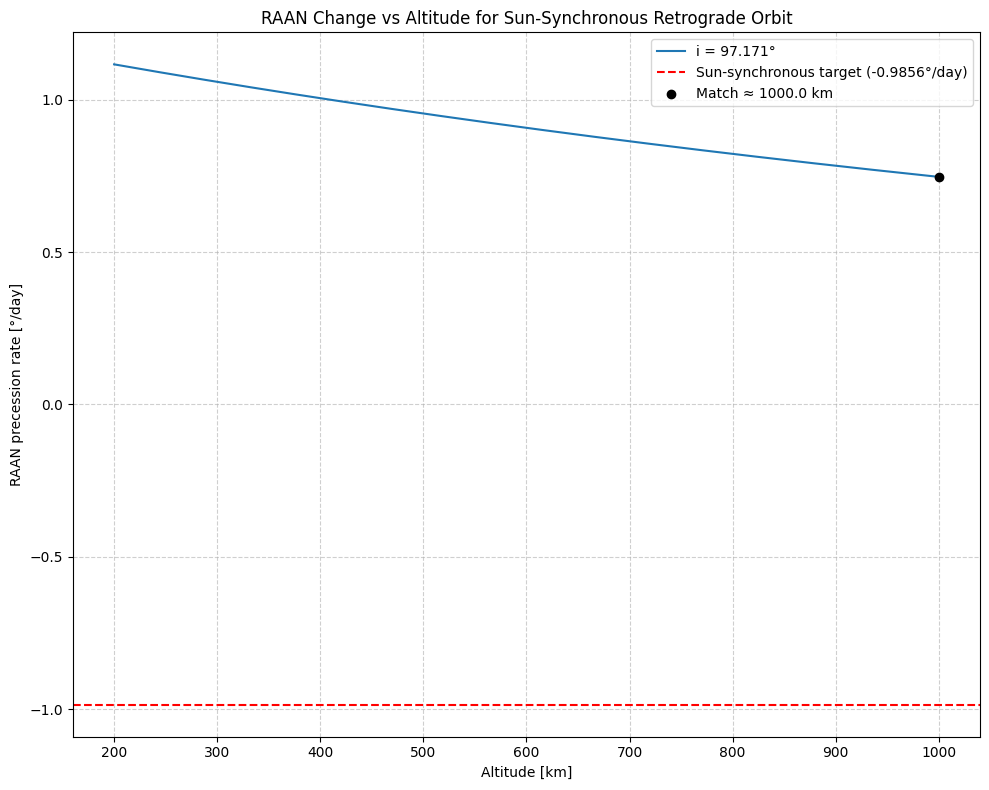

Best match for Sun-synchronous precession at ≈ 1000.0 km altitude
RAAN precession = 0.74714 °/day (target -0.98565 °/day)


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# CONSTANTS
mu = 398600.4418       # km^3/s^2
Re = 6378.137          # km
J2 = 1.08263e-3        # -
target_precession = -360.0 / 365.2422  # deg/day ≈ -0.9856 deg/day
inclination_deg = 97.1715               # SSO inclination (retrograde)
i = np.deg2rad(inclination_deg)

# COMPUTE RAAN PRECESSION FOR ALTITUDE RANGE
altitudes = np.linspace(200, 1000, 200)   # km
raan_rates = []

for h in altitudes:
    a = Re + h
    n = np.sqrt(mu / a**3)
    dOmega_dt = -1.5 * J2 * (Re / a)**2 * n * np.cos(i)   # rad/s
    dOmega_deg_day = np.degrees(dOmega_dt) * 86400        # deg/day
    raan_rates.append(dOmega_deg_day)

raan_rates = np.array(raan_rates)

# ALTITUDE CLOSEST TO TARGET SSO VALUE
idx = np.argmin(np.abs(raan_rates - target_precession))
best_alt = altitudes[idx]
best_rate = raan_rates[idx]

# PLOT
plt.figure(figsize=(10,8))
plt.plot(altitudes, raan_rates, label=f'i = {inclination_deg:.3f}°')
plt.axhline(target_precession, color='r', linestyle='--', label='Sun-synchronous target (-0.9856°/day)')
plt.scatter(best_alt, best_rate, color='k', zorder=5, label=f'Match ≈ {best_alt:.1f} km')
plt.xlabel("Altitude [km]")
plt.ylabel("RAAN precession rate [°/day]")
plt.title("RAAN Change vs Altitude for Sun-Synchronous Retrograde Orbit")
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best match for Sun-synchronous precession at ≈ {best_alt:.1f} km altitude")
print(f"RAAN precession = {best_rate:.5f} °/day (target {target_precession:.5f} °/day)")


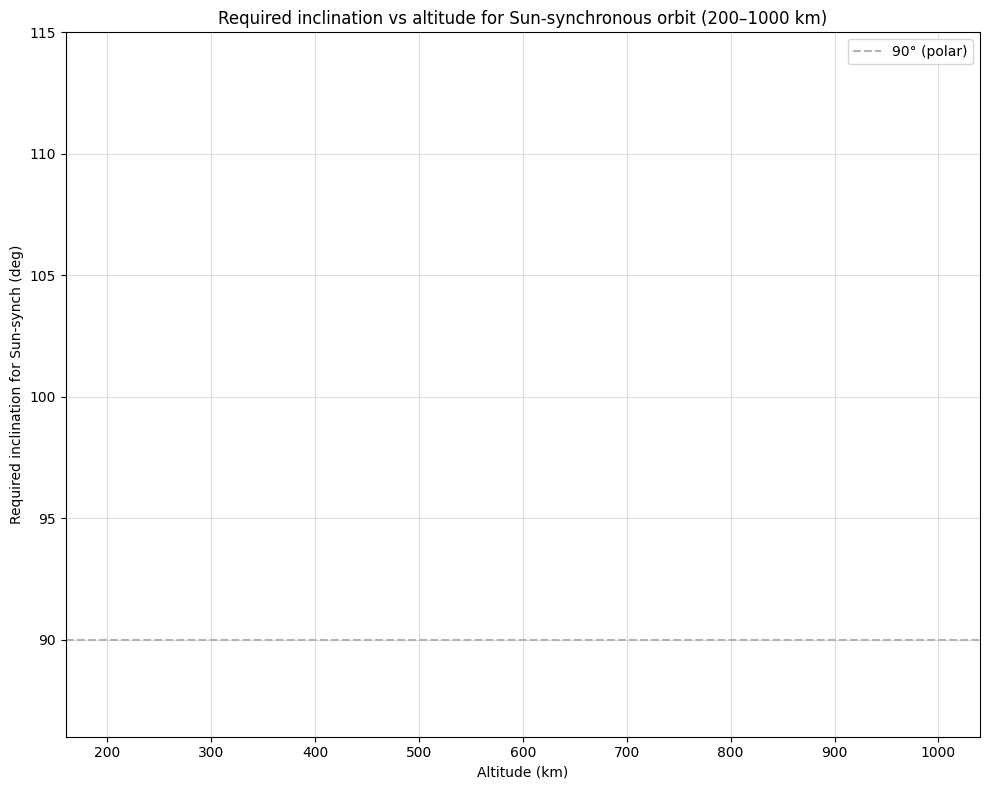

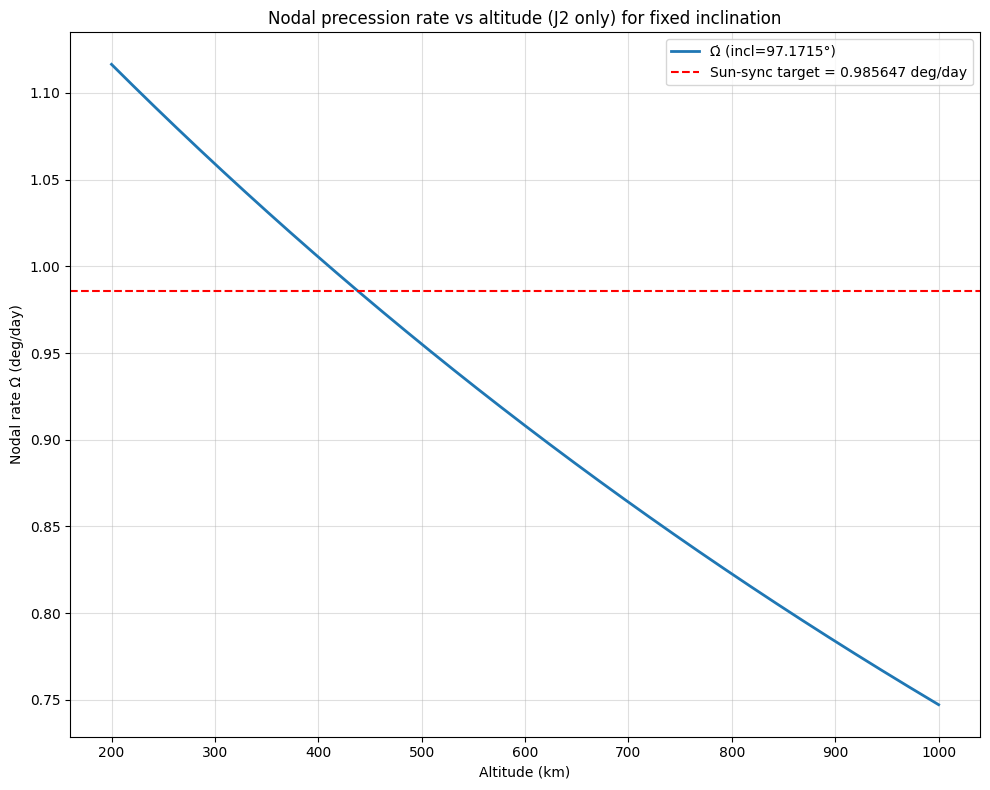

Alt (km)  a (km)     n (deg/day)   cos(i)     i (deg)   Ω̇_j2 (deg/day) at fixed incl
200.000  6578.137  5858.020560   0.110209  83.67261      1.116492
300.000  6678.137  5726.935296   0.116186  83.32799      1.059064
474.066  6852.137  5510.105722   0.127130  82.69619      0.967887
500.000  6878.137  5478.971355   0.128827  82.59819      0.955142
800.000  7178.137  5139.106861   0.149589  81.39689      0.822573
1000.000  7378.137  4931.569865   0.164692  80.52067      0.747140


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
mu = 3.986004418e14          # [m^3/s^2] Earth gravitational parameter
R_e = 6378137.0              # [m] Earth equatorial radius (WGS-84)
J2 = 1.08262668e-3           # Earth's J2
T_year = 365.2422 * 86400.0  # [s] mean tropical year ~365.2422 days

# Target nodal rate for sun-sync (rad/s) -- negative (westward regression)
Omega_dot_target = -2.0 * np.pi / T_year   # [rad/s]

# Altitude range
h_km = np.linspace(200.0, 1000.0, 801)     # km
h = h_km * 1000.0                          # convert to meters
a = R_e + h                                # semi-major axis [m]

# mean motion n [rad/s] for circular orbit
n = np.sqrt(mu / a**3)

# Solve for cos(i) from J2 formula (circular e=0)
cos_i = - (2.0 * Omega_dot_target * a**2) / (3.0 * J2 * R_e**2 * n)
# Numerical safety: values slightly >1 or <-1 may appear due to rounding; mask them
cos_i_clamped = np.clip(cos_i, -1.0, 1.0)
incl_rad = np.arccos(cos_i_clamped)
incl_deg = np.degrees(incl_rad)

# Also compute the nodal rate (deg/day) produced by J2 for a fixed inclination (example)
# Use the inclination you care about; example: 97.1715 deg (from your earlier work)
fixed_incl_deg = 97.1715
fixed_incl_rad = np.radians(fixed_incl_deg)
Omega_dot_j2 = -1.5 * J2 * (R_e**2 / a**2) * n * np.cos(fixed_incl_rad)  # [rad/s]
Omega_dot_j2_deg_per_day = np.degrees(Omega_dot_j2) * 86400.0          # [deg/day]

# Target in deg/day (for plotting reference)
Omega_dot_target_deg_per_day = -np.degrees(Omega_dot_target) * 86400.0

# Plot required inclination vs altitude
plt.figure(figsize=(10, 8))
plt.plot(h_km, incl_deg, lw=2)
plt.grid(True, alpha=0.4)
plt.xlabel('Altitude (km)')
plt.ylabel('Required inclination for Sun-synch (deg)')
plt.title('Required inclination vs altitude for Sun-synchronous orbit (200–1000 km)')
plt.ylim(86, 115)
plt.axhline(90, color='0.7', linestyle='--', label='90° (polar)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot RAAN precession vs altitude for the fixed inclination
plt.figure(figsize=(10, 8))
plt.plot(h_km, Omega_dot_j2_deg_per_day, lw=2, label=f'Ω̇ (incl={fixed_incl_deg:.4f}°)')
plt.axhline(Omega_dot_target_deg_per_day, color='red', linestyle='--',
            label=f'Sun-sync target = {Omega_dot_target_deg_per_day:.6f} deg/day')
plt.grid(True, alpha=0.4)
plt.xlabel('Altitude (km)')
plt.ylabel('Nodal rate Ω̇ (deg/day)')
plt.title('Nodal precession rate vs altitude (J2 only) for fixed inclination')
plt.legend()
plt.tight_layout()
plt.show()

# Print a small sample table for a few altitudes
sample_altitudes_km = [200, 300, 474.066, 500, 800, 1000]
print("Alt (km)  a (km)     n (deg/day)   cos(i)     i (deg)   Ω̇_j2 (deg/day) at fixed incl")
for hk in sample_altitudes_km:
    ai = R_e + hk*1000.0
    ni = np.sqrt(mu/ai**3)
    ni_deg_per_day = np.degrees(ni) * 86400.0
    idx = np.where(np.isclose(h_km, hk, atol=1e-6))[0]
    # find nearest index
    if idx.size == 0:
        idx = (np.abs(h_km-hk)).argmin()
    else:
        idx = idx[0]
    print(f"{hk:7.3f}  {a[idx]/1000.0:8.3f}  {ni_deg_per_day:10.6f}  {cos_i[idx]: .6f}  {incl_deg[idx]:8.5f}  {Omega_dot_j2_deg_per_day[idx]:12.6f}")

# If you want the inclination in the retrograde branch (i > 90°), you can also use:
# incl_deg_alt = 180.0 - incl_deg (for mirrored solutions). For sun-sync typically i>90° (retrograde).
